In [37]:
import numpy as np
import pandas as pd
df = pd.read_csv("train.csv")
print(df.shape)

(891, 12)


In [38]:
print(df.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [39]:
print(df.groupby("Pclass")["Survived"].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [40]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


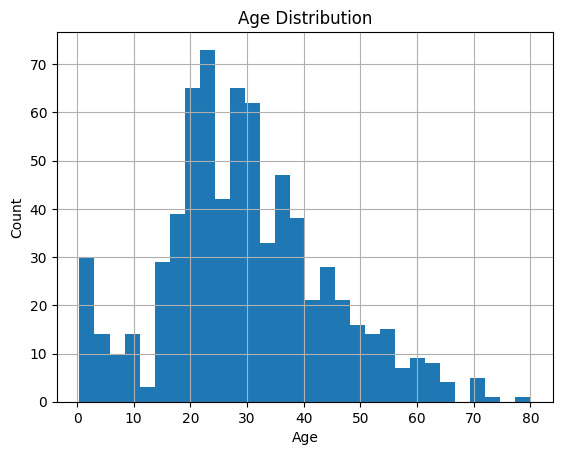

In [41]:
import matplotlib.pyplot as plt
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [42]:
median_age = df["Age"].median()
df["Age"].fillna(median_age,inplace=True)
print(df["Age"].isnull().sum())

0


C:\Users\cheba\AppData\Local\Temp\ipykernel_22364\3133701686.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(median_age,inplace=True)


In [43]:
print(df['Age'].isnull().sum())

0


In [44]:
df = df.drop(columns=["Cabin"])
print(df.shape)

(891, 11)


In [45]:
print(df["Embarked"].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [46]:
df["Embarked"] = df["Embarked"].fillna("S")
print(df["Embarked"].isnull().sum())

0


In [47]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [48]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [49]:
df = df.drop(columns = ["Name","Ticket"])
df.shape

(891, 9)

In [50]:
df["Sex"] = df["Sex"].map({"male":1,"female":0})
df["Sex"].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

In [51]:
df = pd.get_dummies(df,columns=["Embarked"],drop_first=False)

In [52]:
print(df.head())

   PassengerId  Survived  Pclass  Sex   Age  SibSp  Parch     Fare  \
0            1         0       3    1  22.0      1      0   7.2500   
1            2         1       1    0  38.0      1      0  71.2833   
2            3         1       3    0  26.0      0      0   7.9250   
3            4         1       1    0  35.0      1      0  53.1000   
4            5         0       3    1  35.0      0      0   8.0500   

   Embarked_C  Embarked_Q  Embarked_S  
0       False       False        True  
1        True       False       False  
2       False       False        True  
3       False       False        True  
4       False       False        True  


In [53]:
print(df.shape)


(891, 11)


In [54]:
#X = df[["PassengerId","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked_C","Embarked_Q","Embarked_S"]]
X = df.drop(columns=["Survived"])
y = df["Survived"]
print(X.shape)
print(y.shape)

(891, 10)
(891,)


In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)

(712, 10)
(179, 10)


In [56]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth = 3, random_state = 42)
model.fit(X_train,y_train)
print("Model trained successfully!")

Model trained successfully!


In [57]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : " ,accuracy)

Accuracy :  0.7988826815642458


In [58]:
# Try 1 
model = DecisionTreeClassifier(max_depth = 5,random_state = 42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Depth 5: ",accuracy_score(y_test,y_pred))

# Try 2
model = DecisionTreeClassifier(max_depth = 7,random_state = 42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Depth 7: ",accuracy_score(y_test,y_pred))

#Try 3
# model = DecisionTreeClassifier(max_depth = None,random_state = 42)
# model.fit(X_train,y_train)
# y_pred = model.predict(X_test)
# print("No limit: ",accuracy_score(y_test,y_pred))

Depth 5:  0.7988826815642458
Depth 7:  0.8156424581005587


Text(50.722222222222214, 0.5, 'Died')

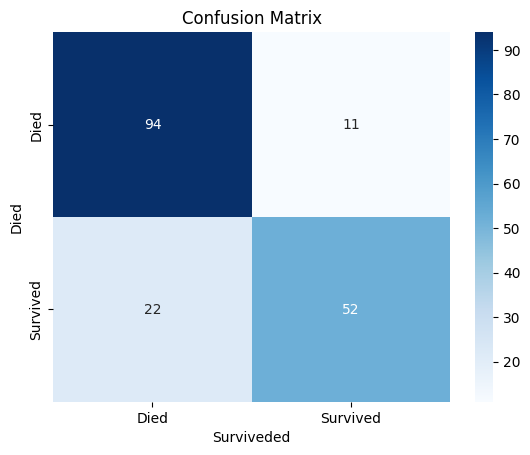

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt = "d",cmap="Blues",
            xticklabels = ["Died","Survived"],
            yticklabels = ["Died","Survived"]
           )
plt.title("Confusion Matrix")
plt.xlabel("Surviveded")
plt.ylabel("Died")
    

In [60]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



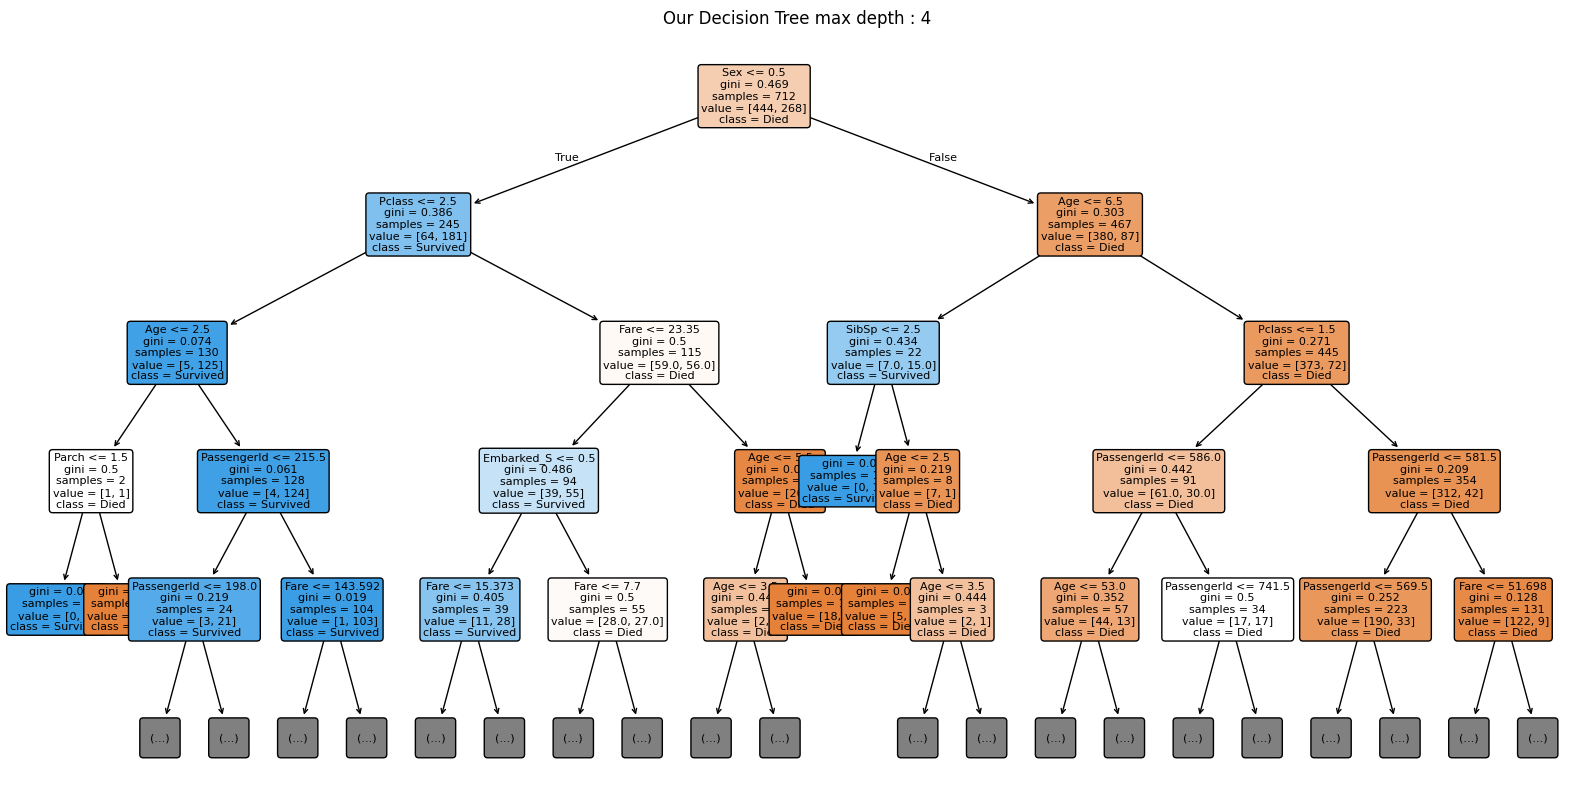

In [61]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model,
          max_depth = 4,
          feature_names = X.columns.tolist(),
          class_names = ["Died","Survived"],
          filled = True,
          rounded = True,
         fontsize = 8)
plt.title("Our Decision Tree max depth : 4")
plt.show()

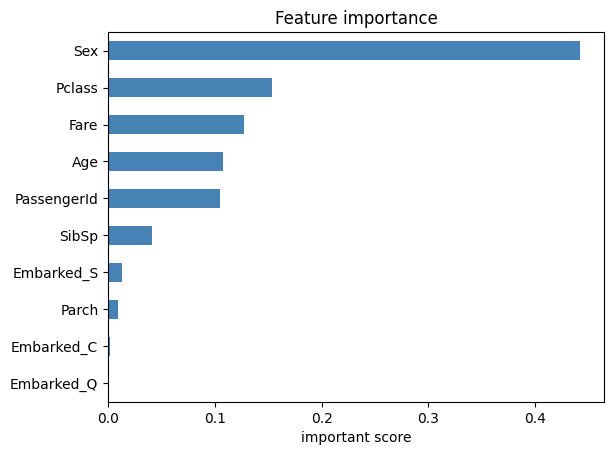

In [62]:
importance = pd.Series(model.feature_importances_,index = X.columns)

importance.sort_values().plot(kind = "barh",color = "steelblue")
plt.title("Feature importance")
plt.xlabel("important score")
plt.show()

In [63]:
## Random Forest Tree

In [64]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators = 7,max_depth = 7,random_state = 42)
model_rf.fit(X_train,y_train)
y_pred_rf = model_rf.predict(X_test)
print("Random Forest Accuracy : ",accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy :  0.8156424581005587


In [65]:
for depth in [5,7,10,15,None]:
    model_rf = RandomForestClassifier(n_estimators = 100,max_depth = depth,random_state = 42)
    model_rf.fit(X_train,y_train)
    y_pred_rf = model_rf.predict(X_test)
    print(f"Tress : {depth} - > Accuracy : {accuracy_score(y_test,y_pred):.4f}")

Tress : 5 - > Accuracy : 0.8156
Tress : 7 - > Accuracy : 0.8156
Tress : 10 - > Accuracy : 0.8156
Tress : 15 - > Accuracy : 0.8156
Tress : None - > Accuracy : 0.8156


In [66]:
# Create family size feature
X["FamilySize"] = X["SibSp"] + X["Parch"] + 1
# +1 includes the passenger themselves!

# Create is_alone feature
X["IsAlone"] = (X["FamilySize"] == 1).astype(int)

print(X[["SibSp","Parch","FamilySize","IsAlone"]].head(10))

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


In [67]:
# Redo train test split with new features
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                     test_size=0.2, 
                                                     random_state=42)

model_rf = RandomForestClassifier(n_estimators=100, 
                                   max_depth=None,
                                   random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("New Accuracy:", accuracy_score(y_test, y_pred_rf))

New Accuracy: 0.8324022346368715


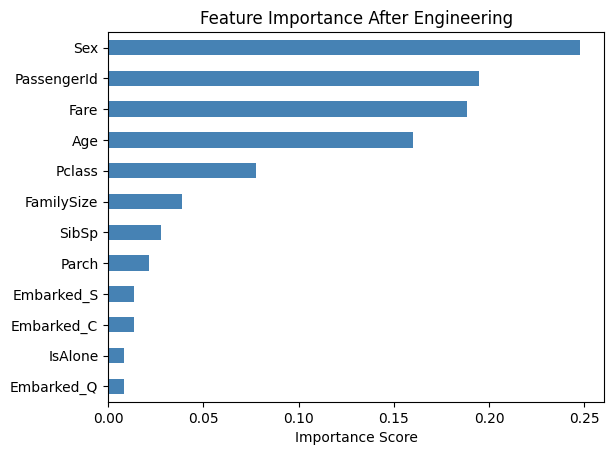

In [68]:
importance = pd.Series(model_rf.feature_importances_, 
                       index=X.columns)
importance.sort_values().plot(kind="barh", 
                               color="steelblue")
plt.title("Feature Importance After Engineering")
plt.xlabel("Importance Score")
plt.show()

In [69]:
import pickle

with open("titanic_model.pkl","wb") as f:
    pickle.dump(model_rf,f)
print("Model saved!")

Model saved!


In [70]:
# Load model from file
with open("titanic_model.pkl","rb") as f:
    loaded_model = pickle.load(f)
print("Model loaded!")

#Test it works
test_pred = loaded_model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,test_pred))

Model loaded!
Accuracy: 0.8324022346368715


In [71]:
# step 1 - verfiy model loads correctly 
with open("titanic_model.pkl","rb") as f:
    load_model = pickle.load(f)

print("Model loaded!")
print("Accuracy:",accuracy_score(y_test,load_model.predict(X_test)))

#step 2 - test with a real passaenger 
# Female , 1st class , age 25, alone,fare 72, embarked S
passenger = pd.DataFrame([[
    1,      # PassengerId
    1,      # Pclass (1st class)
    0,      # Sex (0=female)
    25,     # Age
    0,      # SibSp
    0,      # Parch
    72,     # Fare
    0,      # Embarked_C
    0,      # Embarked_Q
    1,      # Embarked_S
    1,      # FamilySize
    1       # IsAlone
]], columns=X.columns)
prediction = loaded_model.predict(passenger)
print("Prediction:","Survived!" if prediction[0] == 1 else "Died")

Model loaded!
Accuracy: 0.8324022346368715
Prediction: Survived!


In [72]:
passenger = pd.DataFrame([[
    2,      # PassengerId
    3,      # Pclass (1st class)
    1,      # Sex (1=male)
    30,     # Age
    0,      # SibSp
    0,      # Parch
    8,     # Fare
    0,      # Embarked_C
    0,      # Embarked_Q
    1,      # Embarked_S
    1,      # FamilySize
    1       # IsAlone
]], columns=X.columns)
prediction = loaded_model.predict(passenger)
print("Prediction:","Survived!" if prediction[0] == 1 else "Died")

Prediction: Died


In [73]:
!pip install flask


   ---------------------------------------- 0/5 [werkzeug]
   -------------------------------- ------- 4/5 [flask]
   ---------------------------------------- 5/5 [flask]



In [74]:
import os
print(os.getcwd())

C:\Users\cheba\ML Bascis\Projects\Titanic survived prediction
